# **Understanding the Macroeconomic Signals Behind the US Dollar Index (DXY)**

#### **Research Question**
Which macroeconomic indicators influence the US Dollar Index (DXY), and after how many months does their effect appear?

#### **Objectives**
This project aims to:

• Identify the most influential macroeconomic indicators affecting DXY  
• Analyze the direction of influence using linear models  
• Measure the strength of influence using tree-based models  
• Investigate delayed effects using lag features  


In [51]:
#importing main libraries.
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor


## **Data Preparation**

### **Data Loading**

In this section, we load the merged dataset containing macroeconomic indicators and exchange rate data used to analyze movements in the US Dollar Index (DXY).

In [52]:
pwd

'c:\\Users\\DPQUAI250117\\Desktop\\ML_project'

In [53]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 7A52-7B31

 Directory of c:\Users\DPQUAI250117\Desktop\ML_project

03/09/2026  08:12 PM    <DIR>          .
03/09/2026  05:42 PM    <DIR>          ..
03/09/2026  04:17 PM    <DIR>          data
02/23/2026  10:48 AM         2,174,996 final_merged_df - Copy.csv
02/23/2026  10:48 AM         2,174,996 final_merged_df.csv
03/10/2026  09:56 AM            96,859 ML_Project_notebook - Copy.ipynb
03/10/2026  03:55 PM           775,724 ML_Project_notebook.ipynb
03/09/2026  05:16 PM         1,273,066 ML_ProjectFF.ipynb
               5 File(s)      6,495,641 bytes
               3 Dir(s)  337,204,383,744 bytes free


In [54]:
path = os.path.join(os.getcwd() , "final_merged_df.csv")

In [55]:
df= pd.read_csv(path)        # Data Reading


### **Initial Data Exploration**

In [56]:
df.head()

,Date,DXY_Open,DXY_High,DXY_Low,DXY_Close,DXY_Adj_Close,USDCAD_Open,USDCAD_High,USDCAD_Low,USDCAD_Close,...,Owners_Equity_Real_Estate,Inflation_Consumer_Prices,M1_Money_Stock,M2_Money_Stock,Unemployment_Level,MEDCPIM158SFRBCLE,PSAVERT,RHEACBW027SBOG_x,RHEACBW027SBOG_y,GDPC1
0,1994-01-03,96.760002,97.019997,96.540001,96.970001,96.970001,1.3270,1.3300,1.3120,1.3141,...,4985.339,2.931204,1172.6,3502.8,8583.0,3.605814,6.5,73.8723,73.8723,10333.495
1,1994-01-04,96.980003,97.089996,96.459999,96.550003,96.550003,1.3139,1.3185,1.3125,1.3169,...,4985.339,2.931204,1172.6,3502.8,8583.0,3.605814,6.5,73.8723,73.8723,10333.495
2,1994-01-05,96.510002,96.720001,96.389999,96.580002,96.580002,1.3167,1.3226,1.3105,1.3212,...,4985.339,2.931204,1172.6,3502.8,8583.0,3.605814,6.5,73.8723,73.8723,10333.495
3,1994-01-06,96.769997,96.889999,96.300003,96.820000,96.820000,1.3205,1.3240,1.3165,1.3195,...,4985.339,2.931204,1172.6,3502.8,8583.0,3.605814,6.5,73.8723,73.8723,10333.495
4,1994-01-07,96.750000,96.849998,95.989998,96.080002,96.080002,1.3190,1.3248,1.3175,1.3195,...,4985.339,2.931204,1172.6,3502.8,8583.0,3.605814,6.5,73.8723,73.8723,10333.495


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6879 entries, 0 to 6878
Data columns (total 34 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Date                                      6879 non-null   object 
 1   DXY_Open                                  6879 non-null   float64
 2   DXY_High                                  6879 non-null   float64
 3   DXY_Low                                   6879 non-null   float64
 4   DXY_Close                                 6879 non-null   float64
 5   DXY_Adj_Close                             6879 non-null   float64
 6   USDCAD_Open                               6879 non-null   float64
 7   USDCAD_High                               6879 non-null   float64
 8   USDCAD_Low                                6879 non-null   float64
 9   USDCAD_Close                              6879 non-null   float64
 10  USDCAD_Tick_Volume                  

In [58]:
nulls= df.isna().sum()
nulls[nulls > 0]               # There is no null values in the dataset.

Series([], dtype: int64)

 The dataset has a daily frequency based on the Date column and contains no missing values. 
However, some variables may be highly correlated, which could introduce multicollinearity.

### **Time Indexing and Monthly Aggregation**

The dataset originally contains observations at different frequencies.  
To ensure consistency, the data is aggregated to a **monthly frequency**, which allows us to analyze macroeconomic trends over time.

In [59]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')             # sorting date
df_indexed = df.set_index('Date')       # making Date column the dataset index.

In [61]:
df_monthly = df_indexed.resample('ME').last()         # Resampling the dataset to monthly frequency.
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 325 entries, 1994-01-31 to 2021-01-31
Freq: ME
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   DXY_Open                                  325 non-null    float64
 1   DXY_High                                  325 non-null    float64
 2   DXY_Low                                   325 non-null    float64
 3   DXY_Close                                 325 non-null    float64
 4   DXY_Adj_Close                             325 non-null    float64
 5   USDCAD_Open                               325 non-null    float64
 6   USDCAD_High                               325 non-null    float64
 7   USDCAD_Low                                325 non-null    float64
 8   USDCAD_Close                              325 non-null    float64
 9   USDCAD_Tick_Volume                        325 non-null    float64
 10  REAINTRATR

### **Removing Redundant Price Variables**

Price-related columns such as Open, High, Low, and Adjusted Close were removed since they contain similar information about the same asset. Only **DXY_Close** was retained as the representative price variable for the DXY index.

In [122]:
df_dropped= df_monthly.drop(['DXY_Open','DXY_High','DXY_Low','DXY_Adj_Close','USDCAD_Open','USDCAD_High',
                 'USDCAD_Low','USDCAD_Tick_Volume','Combined_Open','Combined_High','Combined_Low','Combined_Adj_Close'],axis=1)

In [123]:
df_dropped.shape

(325, 21)

#### **Correlation Analysis** 
Correlation analysis was performed to identify highly correlated variables.  
Strong correlations between features may introduce multicollinearity, which can affect model interpretation.

In [125]:
df_dropped[['Gross_Domestic_Product','GDPC1']].corr()

,Gross_Domestic_Product,GDPC1
Gross_Domestic_Product,1.000000,0.990304
GDPC1,0.990304,1.000000


In [126]:
df_dropped[['Consumer_Price_Index_Monthly_Change',
'Consumer_Price_Index_All_Urban_Consumers',
'Inflation_Consumer_Prices',
'MEDCPIM158SFRBCLE',]] .corr()    #CPI 

,Consumer_Price_Index_Monthly_Change,Consumer_Price_Index_All_Urban_Consumers,Inflation_Consumer_Prices,MEDCPIM158SFRBCLE
Consumer_Price_Index_Monthly_Change,1.000000,-0.158439,0.084424,0.322507
Consumer_Price_Index_All_Urban_Consumers,-0.158439,1.000000,-0.383455,-0.197301
Inflation_Consumer_Prices,0.084424,-0.383455,1.000000,0.145815
MEDCPIM158SFRBCLE,0.322507,-0.197301,0.145815,1.000000


In [127]:
df_dropped[['M1_Money_Stock','M2_Money_Stock']].corr()

,M1_Money_Stock,M2_Money_Stock
M1_Money_Stock,1.000000,0.727278
M2_Money_Stock,0.727278,1.000000


In [128]:
df_dropped[['RHEACBW027SBOG_x','RHEACBW027SBOG_y','REAINTRATREARAT10Y']].corr()

,RHEACBW027SBOG_x,RHEACBW027SBOG_y,REAINTRATREARAT10Y
RHEACBW027SBOG_x,1.000000,1.000000,-0.749132
RHEACBW027SBOG_y,1.000000,1.000000,-0.749132
REAINTRATREARAT10Y,-0.749132,-0.749132,1.000000


In [129]:
print(df_dropped[['DXY_Close','Combined_Close']].corr())

                DXY_Close  Combined_Close
DXY_Close             1.0             1.0
Combined_Close        1.0             1.0


Correlation analysis revealed that several variables were perfectly or highly correlated, including:

Gross_Domestic_Product, Consumer_Price_Index_All_Urban_Consumers,  
RHEACBW027SBOG_y, M1_Money_Stock, and Combined_Close.

Since these variables contain very similar information, retaining all of them would introduce redundant features. Therefore, only one variable from each correlated pair was kept while the others were removed to reduce redundancy and multicollinearity.

In [130]:
df_dropped.drop(['Gross_Domestic_Product','Consumer_Price_Index_All_Urban_Consumers','RHEACBW027SBOG_y','M1_Money_Stock','Combined_Close'], axis=1 , inplace= True)
df_dropped.columns

Index(['DXY_Close', 'USDCAD_Close', 'REAINTRATREARAT10Y', 'TOTBKCR',
       'Consumer_Price_Index_Monthly_Change', 'Continued_Claims',
       'Delinquency_Rate', 'Federal_Funds_Rate', 'Owners_Equity_Real_Estate',
       'Inflation_Consumer_Prices', 'M2_Money_Stock', 'Unemployment_Level',
       'MEDCPIM158SFRBCLE', 'PSAVERT', 'RHEACBW027SBOG_x', 'GDPC1'],
      dtype='object')

## **Feature Engineering**

### **Lag Variables**

Macroeconomic indicators often affect financial markets with a delay.
To capture these delayed effects, we create lagged versions of each feature (1, 2, and 3 months).
This allows us to investigate **how long it takes for economic signals to influence the DXY index.**

In [72]:
target = 'DXY_Close'

In [73]:
features = [col for col in df_dropped.columns if col != target]

In [74]:
for col in features:
    for lag in [1, 2, 3]:
        df_dropped[f"{col}_lag{lag}"] = df_dropped[col].shift(lag)

In [75]:
print(df_dropped.shape)

(325, 61)


In [76]:
df_dropped = df_dropped.dropna()
df_dropped = df_dropped.sort_index()

### **Train–Test Split**

Because this is a time-series dataset, we split the data chronologically rather than randomly.

• 80% of the data is used for training  
• 20% is used for testing

In [77]:
split_index = int(len(df_dropped) * 0.8)

train_df = df_dropped.iloc[:split_index]
test_df  = df_dropped.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (257, 61)
Test shape: (65, 61)


In [78]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [79]:
y_test.shape

(65,)

### **Feature Scaling**
Macroeconomic data often contains outliers due to economic shocks.

To make the models more robust to extreme values, we apply **Robust Scaling**, which scales features using the median and interquartile range.

In [80]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [81]:
# Transforming numpy array to dataframe
X_train = pd.DataFrame(X_train, index=train_df.index, columns=train_df.drop(columns=[target]).columns)
X_test  = pd.DataFrame(X_test,  index=test_df.index,  columns=test_df.drop(columns=[target]).columns)

In [82]:
X_train.head()

,USDCAD_Close,REAINTRATREARAT10Y,TOTBKCR,Consumer_Price_Index_Monthly_Change,Continued_Claims,Delinquency_Rate,Federal_Funds_Rate,Owners_Equity_Real_Estate,Inflation_Consumer_Prices,M2_Money_Stock,...,MEDCPIM158SFRBCLE_lag3,PSAVERT_lag1,PSAVERT_lag2,PSAVERT_lag3,RHEACBW027SBOG_x_lag1,RHEACBW027SBOG_x_lag2,RHEACBW027SBOG_x_lag3,GDPC1_lag1,GDPC1_lag2,GDPC1_lag3
Date,,,,,,,,,,,,,,,,,,,,,
1994-04-30,0.306485,0.938187,-0.725177,-0.095404,-0.007890,-0.790323,0.236893,-0.799553,0.743177,-0.726877,...,1.100076,0.35,0.20,0.20,-0.805916,-0.795704,-0.763302,-1.383824,-1.313386,-1.267959
1994-05-31,0.309854,0.938187,-0.723857,-0.095404,0.023669,-0.790323,0.405825,-0.799553,0.743177,-0.730831,...,1.100076,0.15,0.35,0.20,-0.806046,-0.795500,-0.763241,-1.383824,-1.313386,-1.267959
1994-06-30,0.311258,0.903002,-0.719231,0.416982,-0.015779,-0.790323,0.669903,-0.799553,0.743177,-0.732945,...,-0.237821,0.15,0.15,0.35,-0.805139,-0.795629,-0.763037,-1.383824,-1.313386,-1.267959
1994-07-31,0.318557,1.006414,-0.713824,0.243643,-0.052268,-0.822581,0.345631,-0.793507,0.743177,-0.727723,...,0.080136,0.40,0.15,0.15,-0.804254,-0.794722,-0.763167,-1.383824,-1.313386,-1.267959
1994-08-31,0.264935,0.895881,-0.710032,0.581786,-0.054241,-0.822581,0.425243,-0.793507,0.743177,-0.731080,...,0.080136,0.45,0.40,0.15,-0.804096,-0.793837,-0.762260,-1.364259,-1.313386,-1.267959


In [83]:
X_train.columns

Index(['USDCAD_Close', 'REAINTRATREARAT10Y', 'TOTBKCR',
       'Consumer_Price_Index_Monthly_Change', 'Continued_Claims',
       'Delinquency_Rate', 'Federal_Funds_Rate', 'Owners_Equity_Real_Estate',
       'Inflation_Consumer_Prices', 'M2_Money_Stock', 'Unemployment_Level',
       'MEDCPIM158SFRBCLE', 'PSAVERT', 'RHEACBW027SBOG_x', 'GDPC1',
       'USDCAD_Close_lag1', 'USDCAD_Close_lag2', 'USDCAD_Close_lag3',
       'REAINTRATREARAT10Y_lag1', 'REAINTRATREARAT10Y_lag2',
       'REAINTRATREARAT10Y_lag3', 'TOTBKCR_lag1', 'TOTBKCR_lag2',
       'TOTBKCR_lag3', 'Consumer_Price_Index_Monthly_Change_lag1',
       'Consumer_Price_Index_Monthly_Change_lag2',
       'Consumer_Price_Index_Monthly_Change_lag3', 'Continued_Claims_lag1',
       'Continued_Claims_lag2', 'Continued_Claims_lag3',
       'Delinquency_Rate_lag1', 'Delinquency_Rate_lag2',
       'Delinquency_Rate_lag3', 'Federal_Funds_Rate_lag1',
       'Federal_Funds_Rate_lag2', 'Federal_Funds_Rate_lag3',
       'Owners_Equity_Real_Esta

### **Multicollinearity Analysis**

Highly correlated variables can distort the interpretation of linear models.

To reduce multicollinearity, we analyze correlations and remove redundant variables before training the models.

In [84]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
original_cols = [
     'USDCAD_Close', 'REAINTRATREARAT10Y', 'TOTBKCR',
       'Consumer_Price_Index_Monthly_Change', 'Continued_Claims',
       'Delinquency_Rate', 'Federal_Funds_Rate',
       'Owners_Equity_Real_Estate', 'Inflation_Consumer_Prices',
        'M2_Money_Stock', 'Unemployment_Level',
       'MEDCPIM158SFRBCLE', 'PSAVERT', 'RHEACBW027SBOG_x', 'GDPC1'
]

X_original = X_train[original_cols].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_original.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_original.values, i)
    for i in range(X_original.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
9,M2_Money_Stock,242.030465
2,TOTBKCR,205.195513
14,GDPC1,98.082804
13,RHEACBW027SBOG_x,44.358707
10,Unemployment_Level,24.580373
4,Continued_Claims,19.014775
6,Federal_Funds_Rate,15.963097
0,USDCAD_Close,12.798840
1,REAINTRATREARAT10Y,12.375949
5,Delinquency_Rate,10.668240


In [85]:
X_train[['M2_Money_Stock','TOTBKCR']].corr()

,M2_Money_Stock,TOTBKCR
M2_Money_Stock,1.000000,0.975103
TOTBKCR,0.975103,1.000000


In [86]:
cols_to_drop = ['TOTBKCR','TOTBKCR_lag1','TOTBKCR_lag2','TOTBKCR_lag3']

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)
X_train.shape

(257, 56)

In [87]:
X_test.shape

(65, 56)

In [88]:
cols = [
     'USDCAD_Close', 'REAINTRATREARAT10Y',
       'Consumer_Price_Index_Monthly_Change', 'Continued_Claims',
       'Delinquency_Rate', 'Federal_Funds_Rate',
       'Owners_Equity_Real_Estate', 'Inflation_Consumer_Prices',
        'M2_Money_Stock', 'Unemployment_Level',
       'MEDCPIM158SFRBCLE', 'PSAVERT', 'RHEACBW027SBOG_x', 'GDPC1'
]

X = X_train[cols].copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
13,GDPC1,96.410697
8,M2_Money_Stock,45.033226
12,RHEACBW027SBOG_x,36.110739
9,Unemployment_Level,22.314323
3,Continued_Claims,18.004076
5,Federal_Funds_Rate,13.992456
1,REAINTRATREARAT10Y,12.355190
0,USDCAD_Close,11.385555
4,Delinquency_Rate,8.879397
6,Owners_Equity_Real_Estate,6.805703


In [89]:
print('TOTBKCR' in X_train.columns)
print('TOTBKCR_lag1' in X_train.columns)

False
False


### **Feature Grouping**

Economic indicators were grouped into thematic blocks (e.g., inflation, labor market, credit, etc.) based on their economic meaning.  
This grouping helps analyze the impact of related indicators on the DXY index more clearly.

In [90]:
#1) Exchange Rate Block
exchange_features = [
    'USDCAD_Close',
    'USDCAD_Close_lag1', 'USDCAD_Close_lag2', 'USDCAD_Close_lag3'
]

In [91]:
# 2) Interest Rate Block
interest_features = [
    'Federal_Funds_Rate',
    'Federal_Funds_Rate_lag1', 'Federal_Funds_Rate_lag2', 'Federal_Funds_Rate_lag3',
    'REAINTRATREARAT10Y',
    'REAINTRATREARAT10Y_lag1', 'REAINTRATREARAT10Y_lag2', 'REAINTRATREARAT10Y_lag3'
]

In [92]:
# 3) Inflation Block
inflation_features = [
    'Consumer_Price_Index_Monthly_Change',
    'Consumer_Price_Index_Monthly_Change_lag1',
    'Consumer_Price_Index_Monthly_Change_lag2',
    'Consumer_Price_Index_Monthly_Change_lag3',

    'Inflation_Consumer_Prices',
    'Inflation_Consumer_Prices_lag1',
    'Inflation_Consumer_Prices_lag2',
    'Inflation_Consumer_Prices_lag3',

    'MEDCPIM158SFRBCLE',
    'MEDCPIM158SFRBCLE_lag1',
    'MEDCPIM158SFRBCLE_lag2',
    'MEDCPIM158SFRBCLE_lag3'
]

In [93]:
# 4) Labor Market Block
labor_features = [
    'Unemployment_Level',
    'Unemployment_Level_lag1', 'Unemployment_Level_lag2', 'Unemployment_Level_lag3',

    'Continued_Claims',
    'Continued_Claims_lag1', 'Continued_Claims_lag2', 'Continued_Claims_lag3'
]

In [94]:
# 5) Credit / Financial Conditions Block
credit_features = [
    'Delinquency_Rate',
    'Delinquency_Rate_lag1', 'Delinquency_Rate_lag2', 'Delinquency_Rate_lag3'
]

In [95]:
# 6) Real Estate / Household Wealth Block
housing_features = [
    'Owners_Equity_Real_Estate',
    'Owners_Equity_Real_Estate_lag1',
    'Owners_Equity_Real_Estate_lag2',
    'Owners_Equity_Real_Estate_lag3',

    'RHEACBW027SBOG_x',
    'RHEACBW027SBOG_x_lag1',
    'RHEACBW027SBOG_x_lag2',
    'RHEACBW027SBOG_x_lag3'
]

In [96]:
# 7) Money / Savings / Output Block
macro_features = [
    'M2_Money_Stock',
    'M2_Money_Stock_lag1', 'M2_Money_Stock_lag2', 'M2_Money_Stock_lag3',

    'PSAVERT',
    'PSAVERT_lag1', 'PSAVERT_lag2', 'PSAVERT_lag3',

    'GDPC1',
    'GDPC1_lag1', 'GDPC1_lag2', 'GDPC1_lag3'
]

In [97]:
feature_groups = {
    "Exchange Rate": exchange_features,
    "Interest Rates": interest_features,
    "Inflation": inflation_features,
    "Labor Market": labor_features,
    "Credit Conditions": credit_features,
    "Housing & Real Estate": housing_features,
    "Money, Savings & Output": macro_features
}

### **Evaluating Feature Groups Individually**

To understand the individual contribution of each macroeconomic indicator, we first evaluated each feature group independently along with its lagged variables.  

This step helps determine whether a specific economic indicator can directly explain movements in the DXY index without the influence of other variables. By isolating feature groups, we can observe the direct explanatory power of each economic factor and identify whether its effect appears immediately or with a time lag.

## **Modeling**

In this section, different machine learning models are used to analyze the relationship between macroeconomic indicators and the DXY index.

The analysis is divided into two main stages:

• Linear models to analyze the **direction of influence**  
• Tree-based models to measure the **strength of influence**

The models evaluated include:

- Linear Models (Ridge and ElasticNet)
- Tree-Based Models (Random Forest and XGBoost)

Model performance is evaluated using the following metrics:
- R² Score
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

###  **Linear Models**

Linear models are used to examine the directional relationship between macroeconomic indicators and the DXY index.
By analyzing model coefficients, we can determine whether an indicator has a positive or negative effect on the target variable.

In [98]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(max_iter=10000)
}

In [99]:
def evaluate_linear_model(model_name, model, X_train, X_test, y_train, y_test):
    best_model = model        #the model and parameter container
    best_params = None        # # These values will be updated if hyperparameter tuning is applied

    # Ridge 
    if model_name == "Ridge":
        param_grid = {"alpha": np.logspace(-4, 2, 20)}

        # Use GridSearchCV with 5-fold cross-validation
        grid = GridSearchCV(model, param_grid, cv=5, scoring="r2")
        grid.fit(X_train, y_train)

        # Store the best model and its optimal parameter
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    # ElasticNet
    elif model_name == "ElasticNet":
        param_grid = {
            "alpha": np.logspace(-4, 1, 10),
            "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
        # Search for the best parameter combination using cross-validation
        tscv = TimeSeriesSplit(n_splits=5)
        grid = GridSearchCV(model, param_grid, cv=tscv, scoring="r2")
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    # Fit the model directly if no hyperparameter tuning is required
    else:
        best_model.fit(X_train, y_train)

    # Generate predictions on the test set
    y_pred = best_model.predict(X_test)

    # Evaluate model performance
    # R² measures the proportion of variance explained by the model
    # RMSE measures the average magnitude of prediction error
    # MAE measures the average absolute prediction error
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Extract model coefficients for feature impact interpretation
    coef_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": best_model.coef_
    })

    # Compute the absolute coefficient values to rank features by the strength of their impact regardless of direction
    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

    # Sort features from the strongest to the weakest effect
    coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

    return {
        "model_name": model_name,
        "best_model": best_model,
        "best_params": best_params,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "coefficients": coef_df
    }

In [100]:
def run_all_groups(feature_groups, models, X_train_full, X_test_full, y_train, y_test):
    # List to store evaluation metrics for all experiments
    summary_rows = []

    # coefficients and parameters
    detailed_results = {}
    for group_name, feature_list in feature_groups.items():

        # Select only the features belonging to the current group
        X_train_group = X_train_full[feature_list]
        X_test_group = X_test_full[feature_list]

        # Create a dictionary entry for this group
        detailed_results[group_name] = {}

        # Apply each model to the current feature group
        for model_name, model in models.items():

            # Train and evaluate the model using the helper function
            result = evaluate_linear_model(
                model_name,
                model,
                X_train_group,
                X_test_group,
                y_train,
                y_test
            )

            # Store detailed model outputs
            detailed_results[group_name][model_name] = result

            # Store summary metrics for comparison
            summary_rows.append({
                "Group": group_name,
                "Model": model_name,
                "R2": result["r2"],
                "RMSE": result["rmse"],
                "MAE": result["mae"],   
                "Best Params": result["best_params"]
            })

            # Print model evaluation results
            print(f"Group: {group_name} | Model: {model_name}")
            print(f"R² Score: {result['r2']:.4f}")
            print(f"RMSE: {result['rmse']:.4f}")
            print(f"MAE: {result['mae']:.4f}")
            print("-" * 50)

    # Convert the summary list into a DataFrame for easier comparison
    summary_df = pd.DataFrame(summary_rows)

    return summary_df, detailed_results

In [ ]:
summary_df, detailed_results = run_all_groups(feature_groups,models, X_train,X_test,y_train,y_test)
# Sort results by the best R² score
summary_df = summary_df.sort_values(by="R2", ascending=False)
summary_df[["Group", "Model", "R2", "RMSE", "MAE", "Best Params"]].head(10)

Group: Exchange Rate | Model: Linear Regression
R² Score: -0.5315
RMSE: 3.7155
MAE: 3.1781
--------------------------------------------------
Group: Exchange Rate | Model: Ridge
R² Score: -0.5339
RMSE: 3.7183
MAE: 3.1909
--------------------------------------------------
Group: Exchange Rate | Model: ElasticNet
R² Score: -1.0297
RMSE: 4.2772
MAE: 3.7195
--------------------------------------------------
Group: Interest Rates | Model: Linear Regression
R² Score: -19.9763
RMSE: 13.7504
MAE: 13.3703
--------------------------------------------------
Group: Interest Rates | Model: Ridge
R² Score: -12.9797
RMSE: 11.2254
MAE: 10.7488
--------------------------------------------------
Group: Interest Rates | Model: ElasticNet
R² Score: -14.2934
RMSE: 11.7410
MAE: 11.2699
--------------------------------------------------
Group: Inflation | Model: Linear Regression
R² Score: -2.2333
RMSE: 5.3985
MAE: 4.5034
--------------------------------------------------
Group: Inflation | Model: Ridge
R² S

c:\Users\DPQUAI250117\AppData\Local\miniconda3\envs\mlpr\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.427e+02, tolerance: 3.107e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\DPQUAI250117\AppData\Local\miniconda3\envs\mlpr\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.377e+01, tolerance: 2.353e+00
  model = cd_fast.enet_coordinate_descent(


Group: Housing & Real Estate | Model: ElasticNet
R² Score: -4.0407
RMSE: 6.7406
MAE: 5.8533
--------------------------------------------------
Group: Money, Savings & Output | Model: Linear Regression
R² Score: -66.4652
RMSE: 24.6599
MAE: 24.3853
--------------------------------------------------
Group: Money, Savings & Output | Model: Ridge
R² Score: -51.6288
RMSE: 21.7803
MAE: 21.1198
--------------------------------------------------


c:\Users\DPQUAI250117\AppData\Local\miniconda3\envs\mlpr\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.132e+01, tolerance: 3.107e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\DPQUAI250117\AppData\Local\miniconda3\envs\mlpr\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.949e+02, tolerance: 3.107e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\DPQUAI250117\AppData\Local\miniconda3\envs\mlpr\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

Group: Money, Savings & Output | Model: ElasticNet
R² Score: -22.5972
RMSE: 14.5842
MAE: 14.1628
--------------------------------------------------


,Group,Model,R2,RMSE,MAE,Best Params
0,Exchange Rate,Linear Regression,-0.531539,3.715492,3.178060,None
1,Exchange Rate,Ridge,-0.533858,3.718304,3.190889,{'alpha': 0.29763514416313164}
2,Exchange Rate,ElasticNet,-1.029658,4.277242,3.719492,"{'alpha': 0.21544346900318845, 'l1_ratio': 0.1}"
10,Labor Market,Ridge,-1.142017,4.394038,3.373045,{'alpha': 100.0}
6,Inflation,Linear Regression,-2.233311,5.398537,4.503368,None
8,Inflation,ElasticNet,-2.427026,5.557904,4.744455,"{'alpha': 0.21544346900318845, 'l1_ratio': 0.1}"
7,Inflation,Ridge,-2.551066,5.657593,4.868593,{'alpha': 100.0}
14,Credit Conditions,ElasticNet,-3.837513,6.603336,5.917290,"{'alpha': 2.782559402207126, 'l1_ratio': 0.9}"
17,Housing & Real Estate,ElasticNet,-4.040654,6.740557,5.853289,"{'alpha': 0.21544346900318845, 'l1_ratio': 0.1}"
15,Housing & Real Estate,Linear Regression,-4.207844,6.851432,5.503349,None


#### **Model Performance**

The results indicate that most feature groups have limited explanatory power when evaluated independently.
This suggests that macroeconomic indicators may not fully explain short-term fluctuations in the DXY index when considered in isolation.

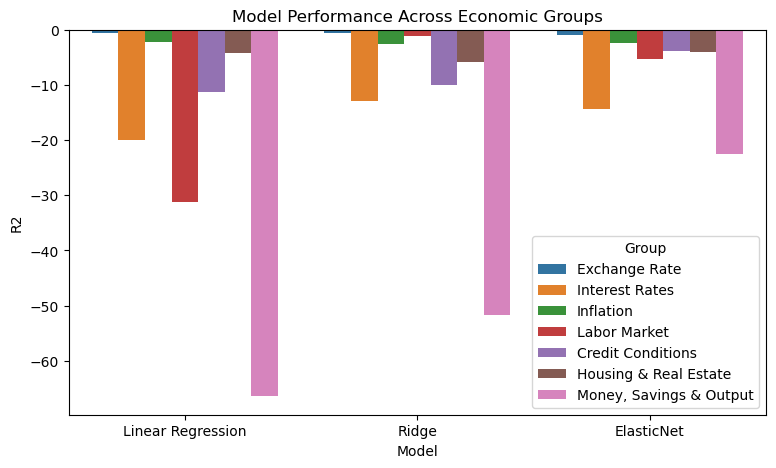

In [103]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=summary_df,
    x="Model",
    y="R2",
    hue="Group"
)

plt.title("Model Performance Across Economic Groups")
plt.show()

#### **Feature Selection Strategy**

Since predictive performance alone may not fully capture the importance of macroeconomic indicators, feature selection is based on multiple complementary criteria:

1. Economic interpretation  
2. Coefficient magnitude in linear models  
3. Feature importance from tree-based models

#### **Coefficient Analysis**
##### Since linear models provide limited predictive power for most macroeconomic groups, they will mainly be used to analyze the direction of relationships through coefficients, while tree-based models will be used later to capture nonlinear interactions.

In [104]:
# Build a full coefficient table from Ridge results across all feature groups
coef_rows = []

for group in detailed_results:
    coef_df = detailed_results[group]["Ridge"]["coefficients"].copy()

    for _, row in coef_df.iterrows():
        feature_name = row["Feature"]

        # Extract the base feature name and lag number
        if "_lag" in feature_name:
            base_feature = feature_name.split("_lag")[0]
            lag = int(feature_name.split("_lag")[1])
        else:
            base_feature = feature_name
            lag = 0

        coef_rows.append({
            "Group": group,
            "Feature": feature_name,
            "Base_Feature": base_feature,
            "Lag": lag,
            "Coefficient": row["Coefficient"],
            "Abs_Coefficient": abs(row["Coefficient"]),
            "Direction": "Positive" if row["Coefficient"] > 0 else "Negative"
        })

coef_analysis = pd.DataFrame(coef_rows)

# Remove the target variable and its lagged versions
coef_analysis = coef_analysis[~coef_analysis["Base_Feature"].isin(["DXY_Close", "DXY_Return"])]

coef_analysis.head()

,Group,Feature,Base_Feature,Lag,Coefficient,Abs_Coefficient,Direction
0,Exchange Rate,USDCAD_Close,USDCAD_Close,0,17.016602,17.016602,Positive
1,Exchange Rate,USDCAD_Close_lag1,USDCAD_Close,1,2.605115,2.605115,Positive
2,Exchange Rate,USDCAD_Close_lag3,USDCAD_Close,3,-0.931258,0.931258,Negative
3,Exchange Rate,USDCAD_Close_lag2,USDCAD_Close,2,-0.415995,0.415995,Negative
4,Interest Rates,REAINTRATREARAT10Y,REAINTRATREARAT10Y,0,1.487813,1.487813,Positive


In [118]:
# Keep only the strongest representation of each feature
# This selects the current value or the lag with the highest absolute coefficient
top_feature_effects = coef_analysis.loc[
    coef_analysis.groupby("Base_Feature")["Abs_Coefficient"].idxmax()
].sort_values("Abs_Coefficient", ascending=False)

top_feature_effects.head()

,Group,Feature,Base_Feature,Lag,Coefficient,Abs_Coefficient,Direction
0,Exchange Rate,USDCAD_Close,USDCAD_Close,0,17.016602,17.016602,Positive
36,Housing & Real Estate,RHEACBW027SBOG_x_lag3,RHEACBW027SBOG_x,3,-2.869964,2.869964,Negative
24,Labor Market,Unemployment_Level_lag3,Unemployment_Level,3,-2.039961,2.039961,Negative
12,Inflation,MEDCPIM158SFRBCLE_lag3,MEDCPIM158SFRBCLE,3,1.762649,1.762649,Positive
4,Interest Rates,REAINTRATREARAT10Y,REAINTRATREARAT10Y,0,1.487813,1.487813,Positive


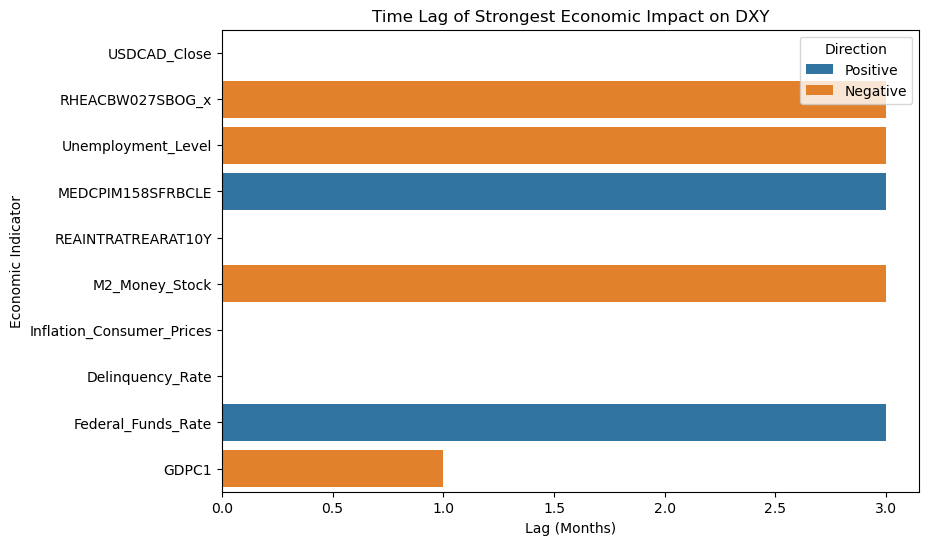

In [106]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=top_feature_effects.head(10),
    x="Lag",
    y="Base_Feature",
    hue="Direction"
)

plt.title("Time Lag of Strongest Economic Impact on DXY")
plt.xlabel("Lag (Months)")
plt.ylabel("Economic Indicator")

plt.show()

### **Tree-Based Models**
Tree-based models such as Random Forest are therefore used to measure the relative importance of each macroeconomic indicator.

#### **Random Forest Model**

The Random Forest model is trained to estimate the relative importance of each feature in explaining movements in the DXY index.
Feature importance scores help identify which economic indicators contribute most to the model.

In [107]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print(f"R²: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

R²: -0.2777
RMSE: 3.3937
MAE: 2.6517


In [108]:
# Feature Importance Table
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values("Importance", ascending=False)
rf_importance.head(15)

,Feature,Importance
0,USDCAD_Close,0.611737
14,USDCAD_Close_lag1,0.138780
12,RHEACBW027SBOG_x,0.030937
50,RHEACBW027SBOG_x_lag1,0.025139
16,USDCAD_Close_lag3,0.024877
3,Continued_Claims,0.022789
44,MEDCPIM158SFRBCLE_lag1,0.012543
28,Delinquency_Rate_lag3,0.012151
45,MEDCPIM158SFRBCLE_lag2,0.011000
15,USDCAD_Close_lag2,0.008440


In [109]:
# Clean the Table and Extract Base Feature + Lag
rf_importance["Base_Feature"] = rf_importance["Feature"].str.replace(r"_lag\d+", "", regex=True)
rf_importance["Lag"] = rf_importance["Feature"].str.extract(r"lag(\d)").fillna(0).astype(int)
rf_importance.head()

,Feature,Importance,Base_Feature,Lag
0,USDCAD_Close,0.611737,USDCAD_Close,0
14,USDCAD_Close_lag1,0.138780,USDCAD_Close,1
12,RHEACBW027SBOG_x,0.030937,RHEACBW027SBOG_x,0
50,RHEACBW027SBOG_x_lag1,0.025139,RHEACBW027SBOG_x,1
16,USDCAD_Close_lag3,0.024877,USDCAD_Close,3


In [119]:
# Keep Only the Strongest Lag for Each Indicator
rf_top_features = rf_importance.loc[
    rf_importance.groupby("Base_Feature")["Importance"].idxmax()
].sort_values("Importance", ascending=False)

rf_top_features["Lag_Label"] = rf_top_features["Lag"].apply(
    lambda x: "Current Month" if x == 0 else f"Lag {x}"
)

rf_top_features.head()

,Feature,Importance,Base_Feature,Lag,Lag_Label
0,USDCAD_Close,0.611737,USDCAD_Close,0,Current Month
12,RHEACBW027SBOG_x,0.030937,RHEACBW027SBOG_x,0,Current Month
3,Continued_Claims,0.022789,Continued_Claims,0,Current Month
44,MEDCPIM158SFRBCLE_lag1,0.012543,MEDCPIM158SFRBCLE,1,Lag 1
28,Delinquency_Rate_lag3,0.012151,Delinquency_Rate,3,Lag 3


#### **Feature Importance Analysis**
The feature importance scores obtained from the Random Forest model provide insight into which macroeconomic indicators have the strongest influence on the DXY index.

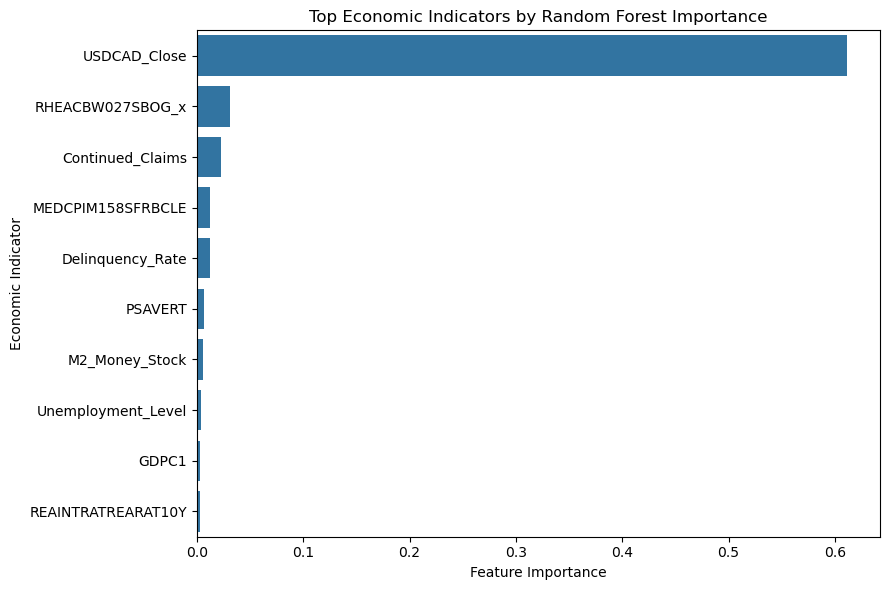

In [111]:
plot_df = rf_top_features.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, x="Importance", y="Base_Feature")
plt.title("Top Economic Indicators by Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Economic Indicator")
plt.tight_layout()
plt.show()

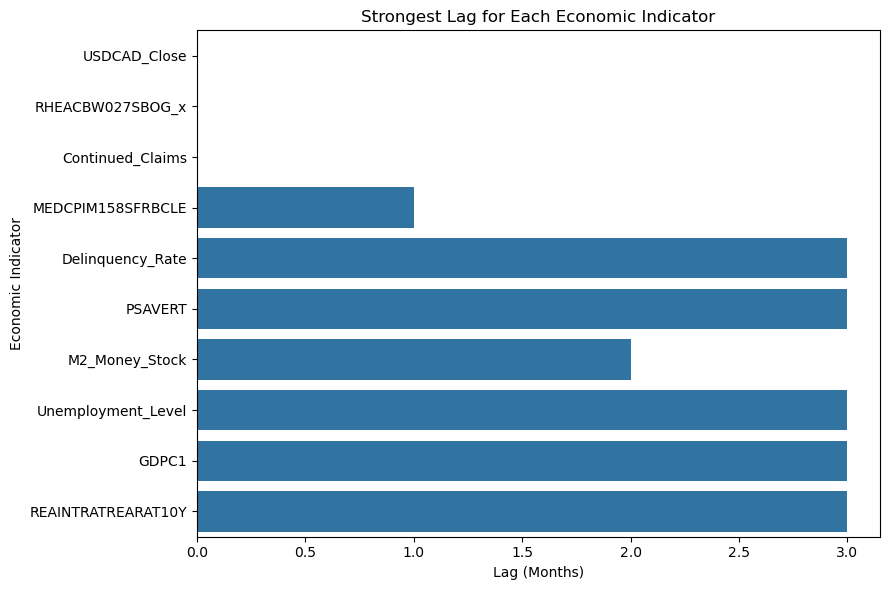

In [112]:
plt.figure(figsize=(9, 6))
sns.barplot(data=rf_top_features.head(10), x="Lag", y="Base_Feature")
plt.title("Strongest Lag for Each Economic Indicator")
plt.xlabel("Lag (Months)")
plt.ylabel("Economic Indicator")
plt.tight_layout()
plt.show()

Exchange rate variables appear to have the strongest influence on the DXY index, while other macroeconomic indicators show smaller but still relevant contributions.

#### **Lag Effect Analysis**

Macroeconomic indicators may influence exchange rates with a delay.  
To capture these delayed effects, lagged variables were included and analyzed.

This allows us to identify how long it takes for economic signals to affect the DXY index.

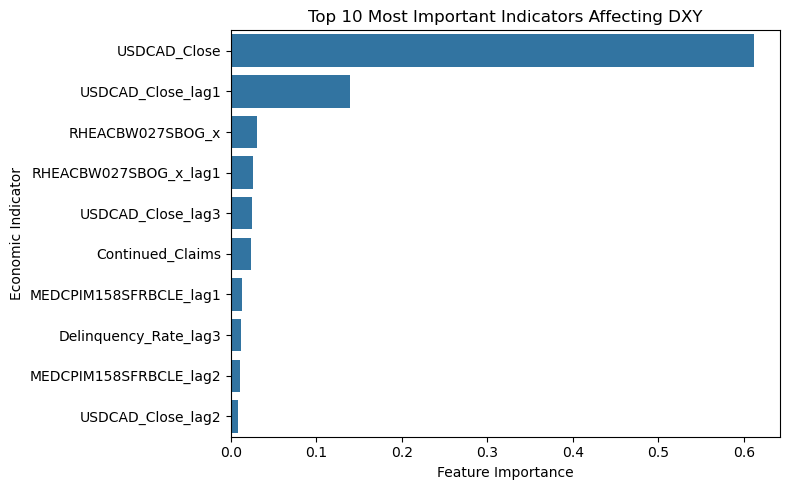

In [113]:
#Feature Ranking by Importance
rf_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_importances = rf_importances.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=rf_importances, x="Importance", y="Feature")

plt.title("Top 10 Most Important Indicators Affecting DXY")
plt.xlabel("Feature Importance")
plt.ylabel("Economic Indicator")

plt.tight_layout()
plt.show()

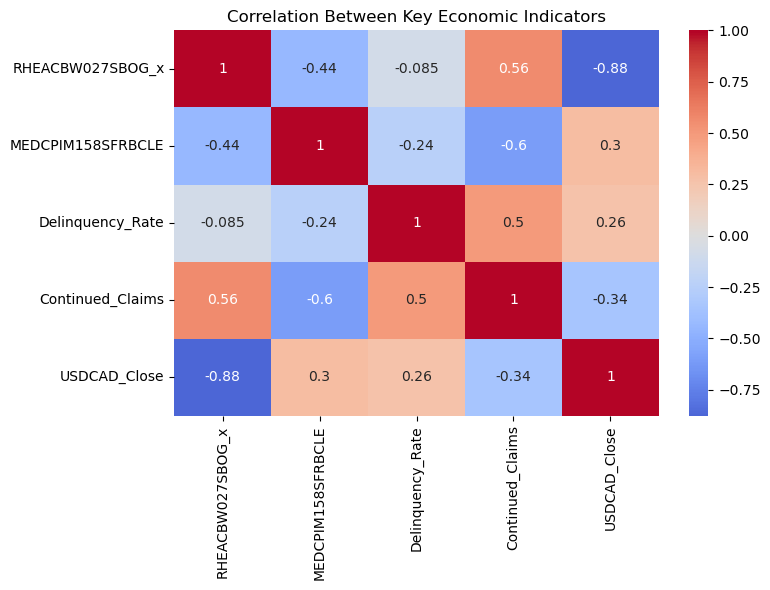

In [116]:
base_features = [f.split("_lag")[0] for f in rf_importances["Feature"].head(10)]

base_features = list(set(base_features))

plt.figure(figsize=(8,6))

corr = X_train[base_features].corr()

sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)

plt.title("Correlation Between Key Economic Indicators")

plt.tight_layout()
plt.show()

The USDCAD exchange rate shows the strongest relationship with the DXY index, which is expected since both variables reflect the strength of the US dollar against other currencies.

## **Key Insights**

Several important observations emerge from the analysis:

• Exchange rate indicators show the strongest relationship with the DXY index  
• Monetary indicators such as inflation and interest rates show moderate influence  
• Some economic indicators affect the DXY index with a time lag

## **Conclusion**

This analysis explored the relationship between macroeconomic indicators and the US Dollar Index.

While individual indicators may have limited predictive power, combining economic interpretation with machine learning models provides useful insights into the factors influencing the DXY index.